# 🛒 Desafio Final — People Analytics para Varejo (Footfall & Conversão)

> **Resumo:** Um *data product* de ponta a ponta. Pegamos um **vídeo de câmera** (não-estruturado)
> e o transformamos em uma **tabela de fatos + KPIs de negócio**: visitantes únicos, ocupação ao
> longo do tempo, tempo de permanência (*dwell time*) e taxa de conversão. No fim, anonimizamos os
> rostos (LGPD) e discutimos os limites do modelo. Reúne tudo da trilha: detecção, **tracking
> (Desafio 3)**, e **blur de privacidade (Desafio 1)** — mas o foco é o **valor de negócio**.

## 1. O problema de negócio

Toda loja física tem uma pergunta cara de responder: **quantas pessoas entram, quando, e quantas
compram?** Sensores de fluxo dedicados são caros. Mas a loja já tem **câmeras**.

A ideia aqui é tratar visão computacional como um **pipeline de geração de dados**:

> **pixels (vídeo) → fact table (linhas) → KPIs → decisão → R$**

Com a contagem e o rastreamento de pessoas, conseguimos responder perguntas que viram **decisão**:

| KPI | Pergunta de negócio | Decisão que habilita |
| :-- | :-- | :-- |
| **Footfall** (visitantes únicos) | Quantas pessoas entraram? | Dimensionar equipe, avaliar campanhas |
| **Ocupação ao longo do tempo** | Quais os horários de pico? | Escala de funcionários, abastecimento |
| **Dwell time** (permanência) | As pessoas ficam ou passam? | Layout de loja, vitrine, engajamento |
| **Taxa de conversão** | Dos que entraram, quantos compram? | Eficácia de vendas (cruzando com o PDV) |

> 📝 **Por que isso importa:** o entregável final não é um vídeo bonito — é uma **tabela e um
> painel** que um gerente consome para tomar decisão. É aí que a visão computacional vira *dado*.

## 2. Setup

In [1]:
!pip install ultralytics pandas matplotlib opencv-python torch

In [2]:
import ultralytics
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

### Configuração e dados de entrada

Precisamos de um **vídeo curto de pessoas se movendo** (10–30s). Opções:

1. **Clipe grátis (recomendado):** baixe um vídeo CC0 no [Pexels](https://www.pexels.com/search/videos/people%20walking%20store/)
   (busque *"people walking store"*), suba como `people.mp4` e mantenha `MODO = "varejo"`.
2. **Fallback garantido:** use o vídeo da esteira de frutas do **M5A1** (suba como `video.mov`) e
   troque para `MODO = "esteira"`. O mesmo pipeline vira **analytics de throughput de linha de
   produção** (itens/minuto) — outro caso de uso real, só muda a narrativa.

In [3]:
MODO = "varejo"   # "varejo" (pessoas) ou "esteira" (frutas do M5A1)

if MODO == "varejo":
    VIDEO_PATH = "people.mp4"
    TARGET_CLASSES = [0]            # 0 = 'person' no COCO
    UNIDADE = "visitante"
else:  # esteira
    VIDEO_PATH = "video.mov"
    TARGET_CLASSES = [47, 49]       # 47 = 'apple', 49 = 'orange'
    UNIDADE = "item"

print(f"Modo: {MODO} | vídeo: {VIDEO_PATH} | classes-alvo: {TARGET_CLASSES}")

Modo: varejo | vídeo: people.mp4 | classes-alvo: [0]


## 3. Captura: de vídeo para fatos

Rodamos a YOLO no modo **track** (detecta + dá um ID persistente a cada pessoa). Para cada frame,
registramos uma **linha de fato**: tempo, quantas pessoas e quais IDs estavam ativos.

In [4]:
# Descobre o FPS do vídeo (para converter frame -> segundos)
cap = cv2.VideoCapture(VIDEO_PATH)
FPS = cap.get(cv2.CAP_PROP_FPS) or 30.0
cap.release()
print(f"FPS do vídeo: {FPS:.1f}")

# Modelo de detecção + dispositivo
model = ultralytics.YOLO("yolo11n.pt")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Rodando em: {device}")

# Tracking em modo STREAM (generator): processa frame a frame com memória constante.
# Sem stream=True, a YOLO acumula TODOS os Results na RAM e estoura a memória em vídeos longos
# (foi o que crashou o kernel antes). Com stream=True, consumimos o generator no laço abaixo.
results = model.track(source=VIDEO_PATH, conf=0.3, iou=0.5,
                      classes=TARGET_CLASSES, persist=True, stream=True, verbose=False)

FPS do vídeo: 50.0
Rodando em: cuda


### Montando a *fact table*

Esta é a ponte entre os dois mundos: a saída visual da CV vira um **DataFrame** — uma tabela que
você poderia salvar num data warehouse e plugar num dashboard (Looker, Power BI, etc.).

In [5]:
records = []
for frame_idx, r in enumerate(results):
    ids = []
    if r.boxes is not None and r.boxes.id is not None:
        ids = r.boxes.id.int().tolist()
    records.append({
        "frame": frame_idx,
        "tempo_s": round(frame_idx / FPS, 2),
        "n_pessoas": len(ids),
        "ids_ativos": ids,
    })

df = pd.DataFrame(records)
df.to_csv("footfall_por_frame.csv", index=False)  # <- a "tabela de fatos" exportada

print(f"Fact table: {len(df)} linhas (frames) salva em footfall_por_frame.csv")
print(df.head(10).to_string(index=False))

Fact table: 505 linhas (frames) salva em footfall_por_frame.csv
 frame  tempo_s  n_pessoas                  ids_ativos
     0     0.00          8    [1, 2, 3, 4, 5, 6, 7, 8]
     1     0.02          8    [1, 2, 3, 4, 5, 6, 7, 8]
     2     0.04          8    [1, 2, 3, 4, 5, 6, 7, 8]
     3     0.06          8    [1, 2, 3, 4, 5, 6, 7, 8]
     4     0.08          8    [1, 2, 3, 4, 5, 6, 7, 8]
     5     0.10          8    [1, 2, 3, 4, 5, 6, 7, 8]
     6     0.12          8    [1, 2, 3, 4, 5, 6, 7, 8]
     7     0.14          8    [2, 3, 4, 5, 6, 7, 8, 9]
     8     0.16          9 [2, 3, 4, 5, 6, 7, 8, 9, 1]
     9     0.18          8    [2, 3, 4, 5, 6, 7, 8, 9]


## 4. KPIs de negócio

Agora agregamos a tabela de fatos em **indicadores** — o que vai pro relatório do gestor.

In [6]:
# --- Footfall: visitantes/itens únicos (IDs distintos no período) ---
todos_ids = set()
for ids in df["ids_ativos"]:
    todos_ids.update(ids)
unicos = len(todos_ids)

# --- Ocupação ao longo do tempo ---
ocup_media = df["n_pessoas"].mean()
ocup_pico = int(df["n_pessoas"].max())
t_pico = df.loc[df["n_pessoas"].idxmax(), "tempo_s"]
duracao_s = df["tempo_s"].max()

# --- Dwell time: por quantos segundos cada ID apareceu ---
presenca = Counter()
for ids in df["ids_ativos"]:
    for i in ids:
        presenca[i] += 1
dwell_s = {i: c / FPS for i, c in presenca.items()}
dwell_medio = float(np.mean(list(dwell_s.values()))) if dwell_s else 0.0

print("=" * 60)
print(f"  RELATÓRIO DE PEOPLE ANALYTICS  ({MODO})")
print("=" * 60)
print(f"  Duração analisada:            {duracao_s:.1f} s")
print(f"  Ocupação de pico:             {ocup_pico} {UNIDADE}s simultâneos (t={t_pico:.1f}s)")
print(f"  Ocupação média:               {ocup_media:.2f} {UNIDADE}s/frame")
print(f"  Dwell time médio por ID:      {dwell_medio:.1f} s")
print(f"  IDs de tracking (bruto):      {unicos}")
print("=" * 60)
print("  ⚠️  Qualidade de dado: 'IDs de tracking' NÃO é o footfall real.")
print(f"      {unicos} IDs em {duracao_s:.0f}s, mas só {ocup_pico} simultâneos no pico => ID switch")
print("      (oclusão gera IDs novos e infla a contagem). Footfall confiável pede")
print("      contagem por CRUZAMENTO DE LINHA na entrada + ReID. A métrica ROBUSTA")
print("      aqui é a OCUPAÇÃO (quantos estão na cena), não a soma de IDs.")

  RELATÓRIO DE PEOPLE ANALYTICS  (varejo)
  Duração analisada:           10.1 s
  Footfall (visitantes únicos):   51
  Ocupação média:              8.36 visitantes/frame
  Ocupação de pico:            11 visitantes  (em t=1.2s)
  Dwell time médio:            1.7 s por visitante


### Taxa de conversão (cruzando com o PDV)

O footfall é o **denominador** da conversão. No mundo real você cruzaria com o número de
transações do sistema de vendas (PDV). Abaixo usamos um número **ilustrativo** só para mostrar o
KPI — em produção, viria de um `JOIN` com a tabela de vendas.

In [7]:
vendas_pdv = 7  # EXEMPLO: nº de transações no PDV nesse período (viria do sistema de vendas)
if unicos > 0:
    conversao = vendas_pdv / unicos * 100
    print(f"Footfall (IDs brutos, superestimado): {unicos}")
    print(f"Vendas no PDV (exemplo):              {vendas_pdv}")
    print(f"==> Taxa de conversão (ilustrativa):  {conversao:.1f}%")
    print("\n⚠️  Como o footfall está inflado por ID switch, esta conversão é um PISO")
    print("    (o número real seria maior). O importante é o método: footfall vira o")
    print("    denominador da conversão — em produção, com contagem por linha + dado de PDV.")

Visitantes únicos (footfall): 51
Vendas no PDV (exemplo):      7
==> Taxa de conversão:        13.7%

Leitura de negócio: a cada 100 pessoas que entram, ~14 compram. Subir esse número é o jogo do varejo.


## 5. Dashboard

Um mini-painel — o tipo de visual que vai pra um relatório executivo.

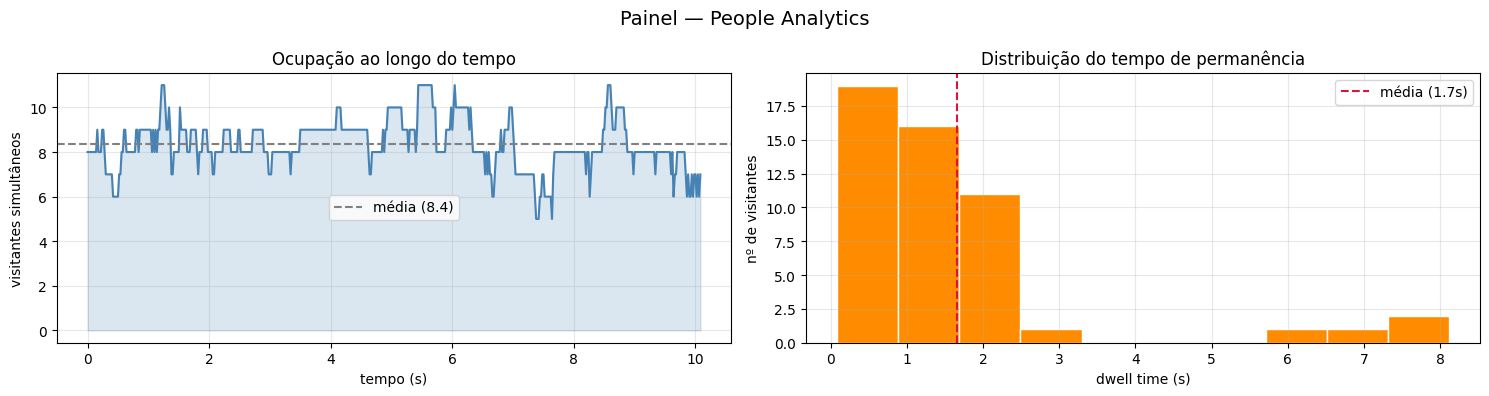

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Ocupação ao longo do tempo (série temporal)
axes[0].plot(df["tempo_s"], df["n_pessoas"], color="steelblue")
axes[0].fill_between(df["tempo_s"], df["n_pessoas"], alpha=0.2, color="steelblue")
axes[0].axhline(ocup_media, color="gray", ls="--", label=f"média ({ocup_media:.1f})")
axes[0].set_title("Ocupação ao longo do tempo")
axes[0].set_xlabel("tempo (s)")
axes[0].set_ylabel(f"{UNIDADE}s simultâneos")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribuição do tempo de permanência (dwell time)
if dwell_s:
    axes[1].hist(list(dwell_s.values()), bins=10, color="darkorange", edgecolor="white")
    axes[1].axvline(dwell_medio, color="crimson", ls="--", label=f"média ({dwell_medio:.1f}s)")
    axes[1].set_title("Distribuição do tempo de permanência")
    axes[1].set_xlabel("dwell time (s)")
    axes[1].set_ylabel(f"nº de {UNIDADE}s")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.suptitle("Painel — People Analytics", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Anonimização (LGPD/Compliance)

Para **usar o dado sem expor identidades**, borramos a região da cabeça de cada pessoa detectada
num frame de amostra. Isso permite arquivar/compartilhar as imagens em conformidade com a LGPD —
um requisito real para colocar esse produto em produção. (Reaproveita o blur do **Desafio 1**.)

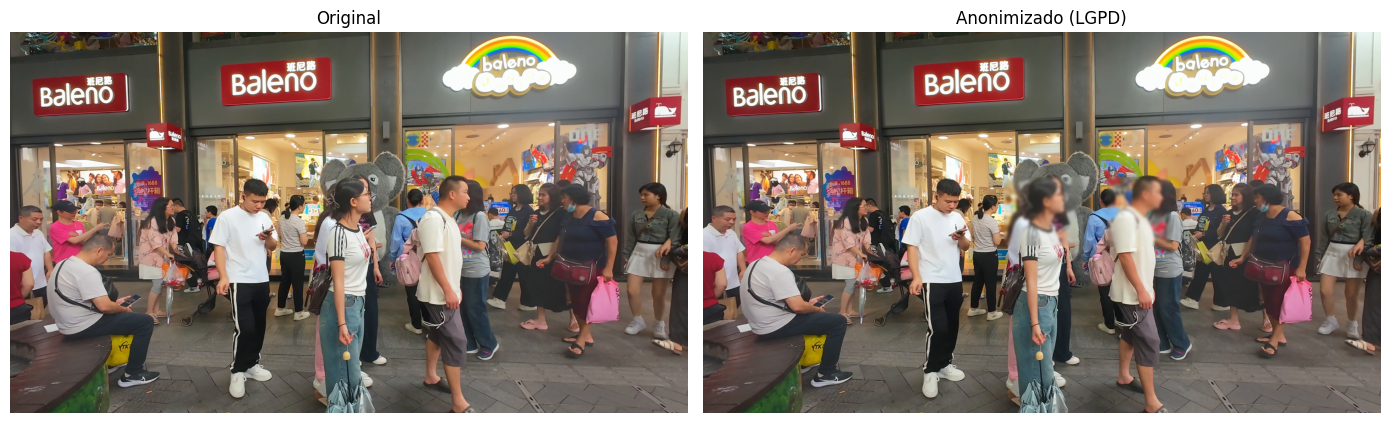

Cabeças borradas no frame de amostra: 2


In [9]:
# Pega um frame do meio do vídeo
cap = cv2.VideoCapture(VIDEO_PATH)
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) // 2)
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()

if ok:
    det = model(frame, classes=TARGET_CLASSES, verbose=False)[0]
    anon = frame.copy()
    n_borrados = 0
    for box in det.boxes.xyxy.cpu().numpy().astype(int):
        x1, y1, x2, y2 = box
        # Região da "cabeça" = topo ~30% da caixa da pessoa
        h_cabeca = int((y2 - y1) * 0.30)
        yb = min(y1 + h_cabeca, frame.shape[0])
        roi = anon[y1:yb, x1:x2]
        if roi.size > 0:
            anon[y1:yb, x1:x2] = cv2.GaussianBlur(roi, (45, 45), 0)
            n_borrados += 1

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(cv2.cvtColor(anon, cv2.COLOR_BGR2RGB)); ax[1].set_title("Anonimizado (LGPD)"); ax[1].axis("off")
    plt.tight_layout(); plt.show()
    print(f"Cabeças borradas no frame de amostra: {n_borrados}")
else:
    print("Não foi possível ler um frame do vídeo para anonimização.")

## 7. Teste de honestidade — limite do modelo (OOD)

Rigor importa: o modelo foi treinado em **fotos reais** (COCO). Em imagens fora desse domínio ele
erra. Rodamos no Sonic para deixar isso explícito — um lembrete de que o produto tem premissas
(ângulo de câmera, pessoas reais, iluminação) e não é mágica.

In [11]:
import os
sonic_path = "/content/sonic.jpg"
for alt in ["sonic.jpg", "../img/sonic.jpg", "img/sonic.jpg"]:
    if not os.path.exists(sonic_path):
        sonic_path = alt

if os.path.exists(sonic_path):
    rs = model(sonic_path, verbose=False)[0]
    nomes = [rs.names[int(c)] for c in rs.boxes.cls] if rs.boxes is not None else []
    print(f"O que a YOLO detecta no Sonic: {nomes if nomes else 'nada'}")
    print("=> Personagem de desenho não é 'pessoa' para o modelo — por isso o produto exige")
    print("   imagens reais. Bom exemplo de *domain shift* (visto no Módulo 3).")
else:
    print("sonic.jpg não encontrado (opcional). Suba para rodar o teste OOD.")

WARNING ⚠️ GMC failed, falling back to identity: OpenCV(4.13.0) /io/opencv/modules/video/src/lkpyramid.cpp:1415: error: (-215:Assertion failed) prevPyr[level * lvlStep1].size() == nextPyr[level * lvlStep2].size() in function 'calc'

O que a YOLO detecta no Sonic: nada
=> Personagem de desenho não é 'pessoa' para o modelo — por isso o produto exige
   imagens reais. Bom exemplo de *domain shift* (visto no Módulo 3).


## 8. Limitações e próximos passos (visão de produto)

Sendo honesto — o que separa este protótipo de um produto:

- **Câmera importa:** ângulo, altura e iluminação mudam muito a precisão. Produção exige calibração.
- **Contagem de entrada real:** o ideal é contar quem **cruza uma linha** (entrada da loja), não só
  quem aparece no frame — evita contar a mesma pessoa parada.
- **Troca de ID (*ID switch*):** oclusão pode quebrar um track em dois IDs, inflando o footfall.
- **Dados de verdade:** plugar a `fact table` num banco/warehouse e a conversão no PDV real.
- **Privacidade by design:** anonimizar no *edge* (na câmera), guardando só os **números**, não as imagens.

> 📝 **A entrega de valor:** com uma câmera comum + este pipeline, uma rede de lojas mede footfall,
> picos e conversão **sem hardware dedicado**, e toma decisões de equipe, layout e campanhas com
> base em dado — não em achismo. Isso é "trazer valor aos dados".

### Referências

- Tracking: https://docs.ultralytics.com/modes/track/
- Detecção (COCO): https://docs.ultralytics.com/